In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/Users/jasleenkaur/Financial-Dashboard/data/processed/loan_default_cleaned.csv")

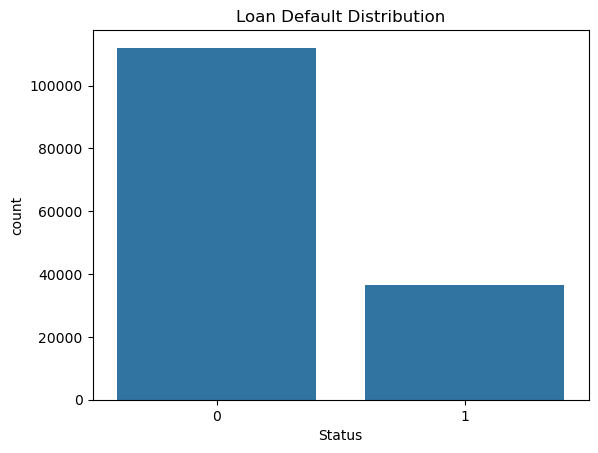


Loan Status Distribution
Status
0    112031
1     36639
Name: count, dtype: int64

Percentage Distribution
Status
0    75.36
1    24.64
Name: proportion, dtype: float64


In [21]:
sns.countplot(data=df, x='Status')

plt.title("Loan Default Distribution")
plt.show()

print("\nLoan Status Distribution")
print(df['Status'].value_counts())

print("\nPercentage Distribution")
print(round(df['Status'].value_counts(normalize=True) * 100,2))

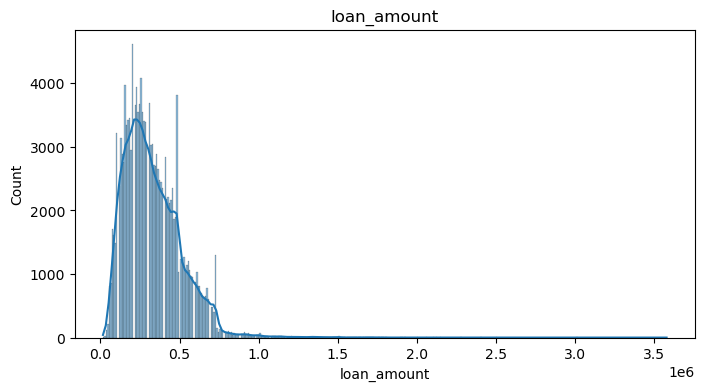

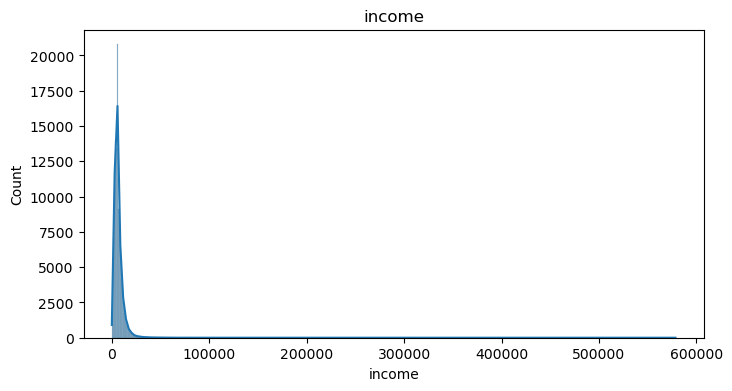

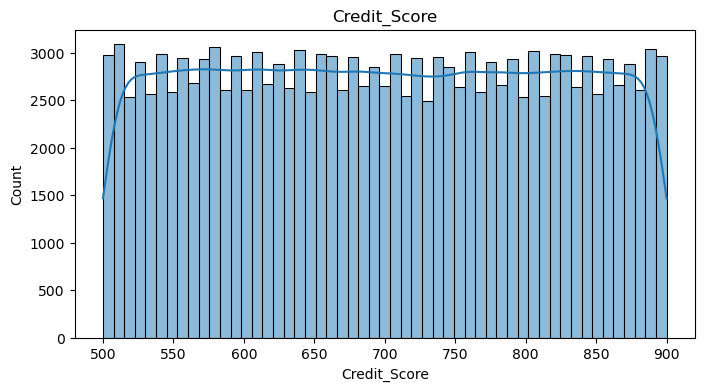

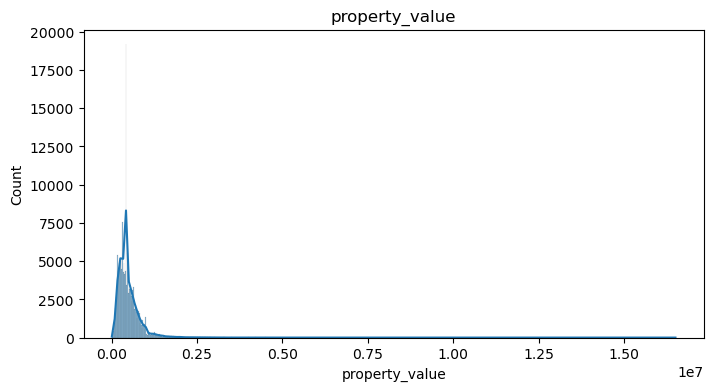

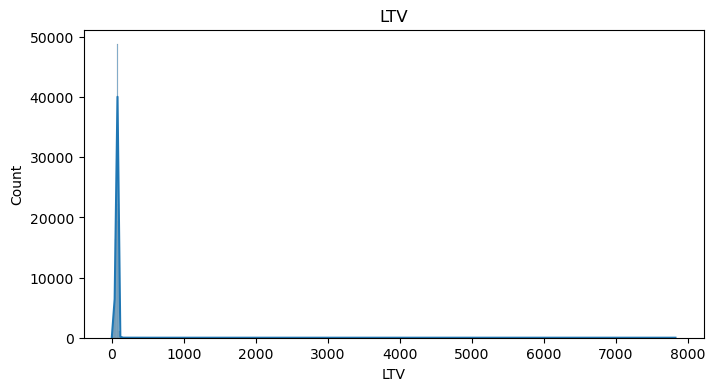

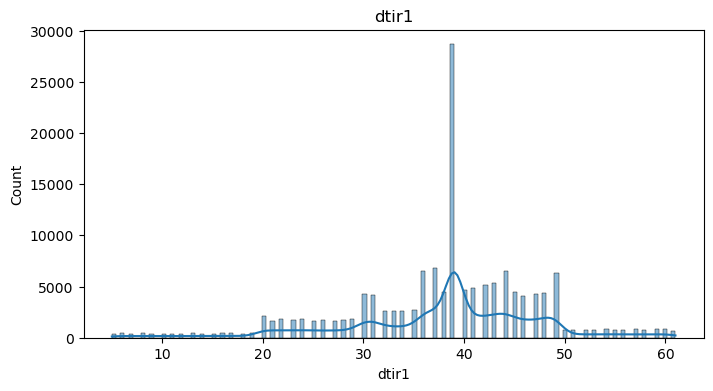

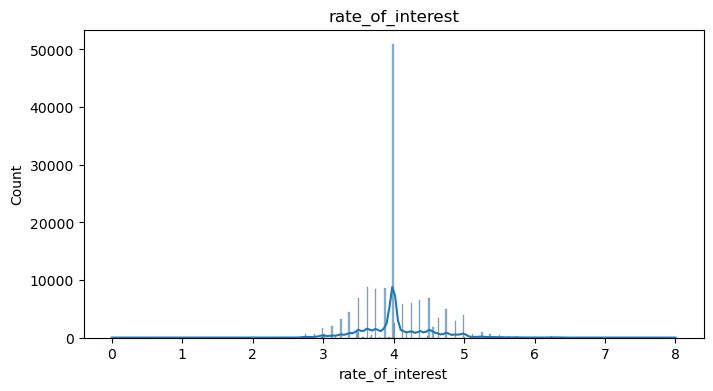

In [15]:
num_cols = [
    'loan_amount',
    'income',
    'Credit_Score',
    'property_value',
    'LTV',
    'dtir1',
    'rate_of_interest'
]

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [16]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum()/len(df))*100
})

missing[missing['Missing Values'] > 0].sort_values(
    by='Percentage',
    ascending=False
)

,Missing Values,Percentage


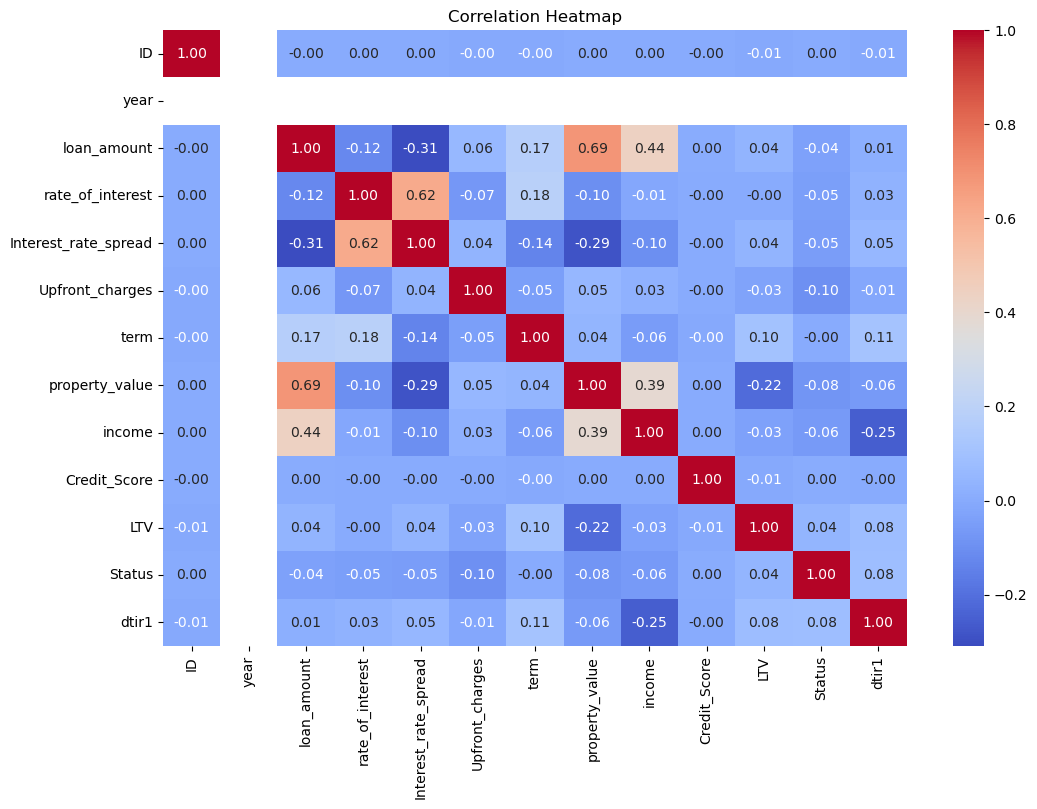

In [17]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

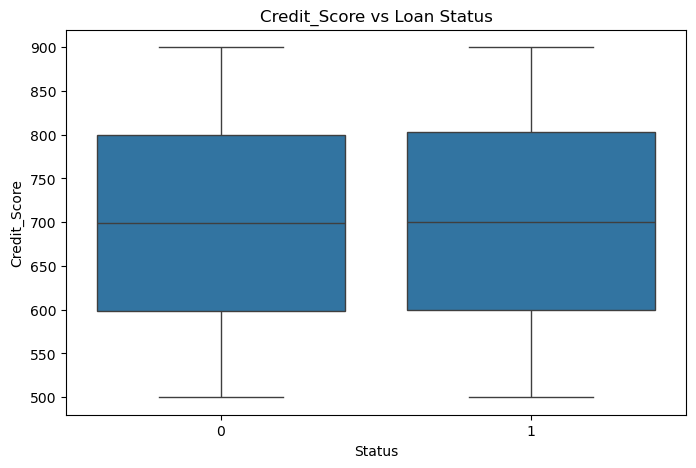

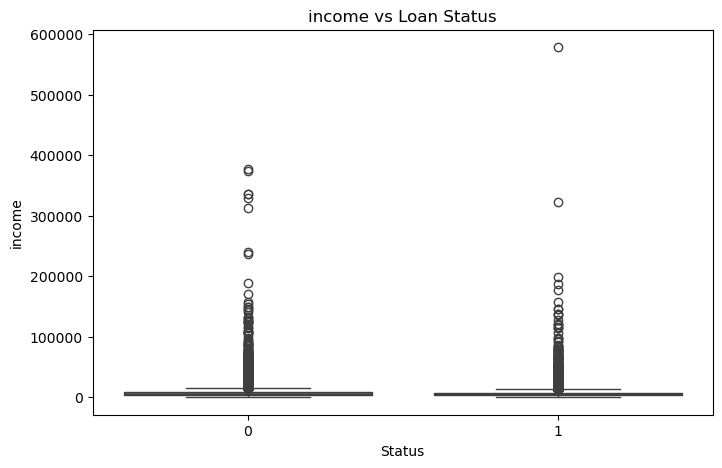

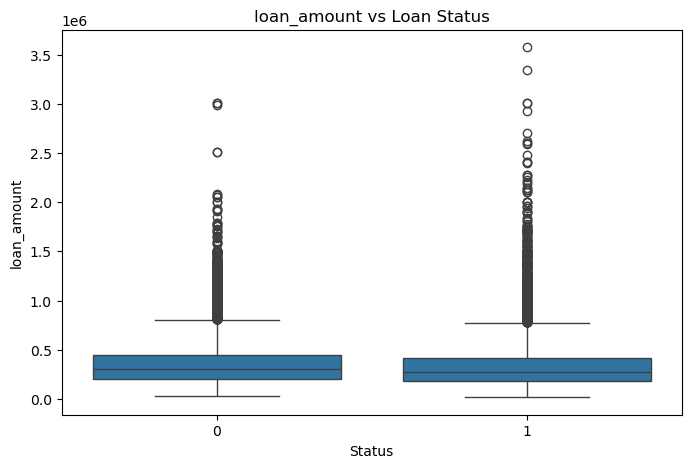

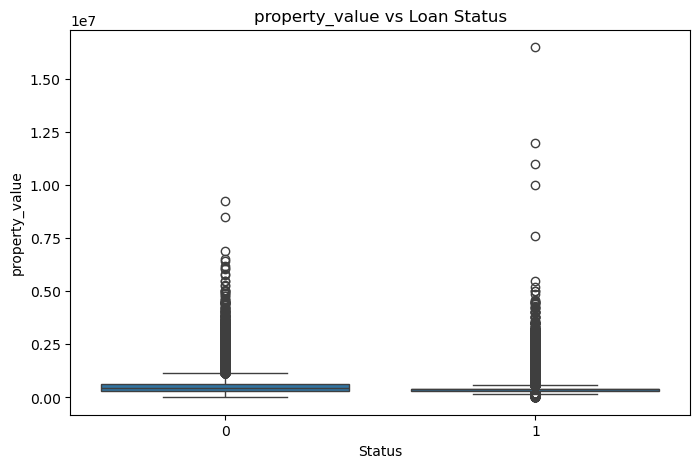

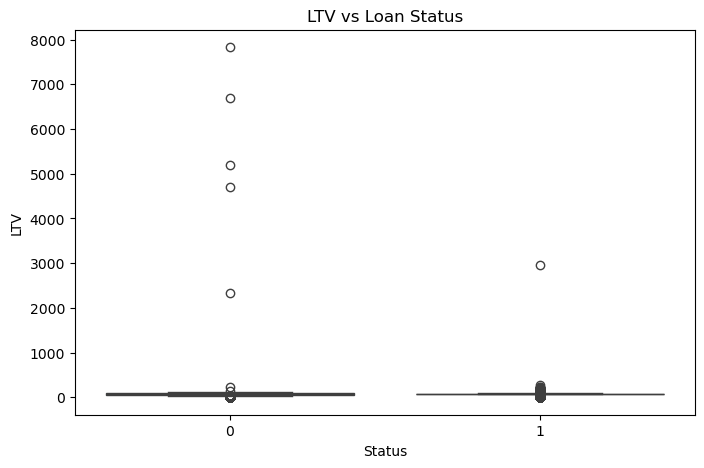

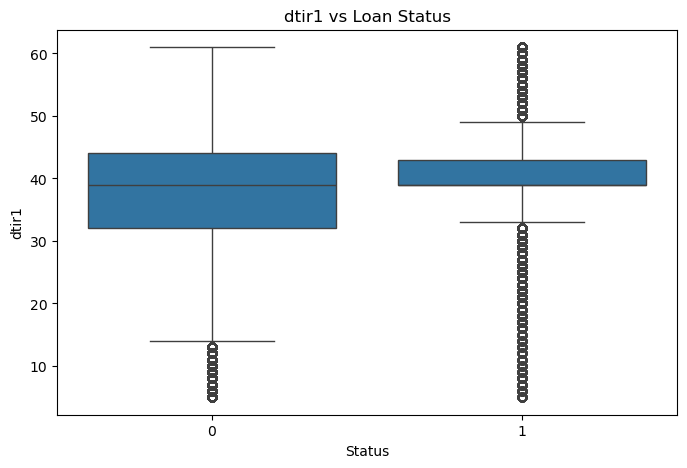

In [18]:
features = [
    'Credit_Score',
    'income',
    'loan_amount',
    'property_value',
    'LTV',
    'dtir1'
]

for col in features:
    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x='Status',
        y=col
    )

    plt.title(f"{col} vs Loan Status")
    plt.show()

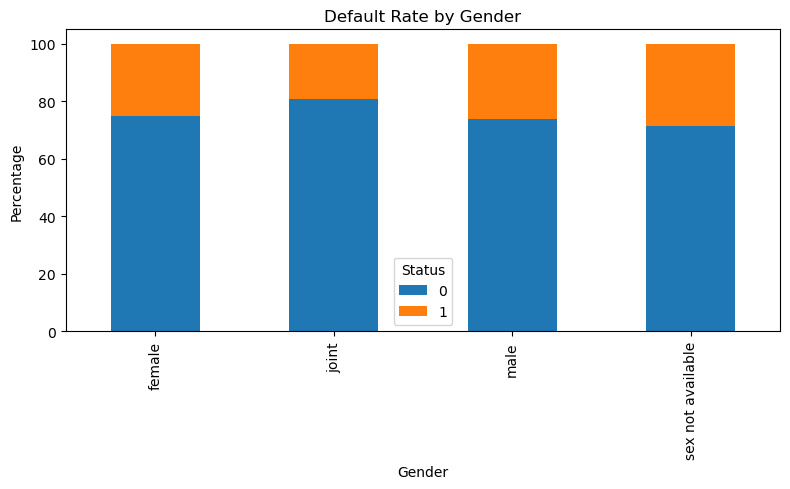

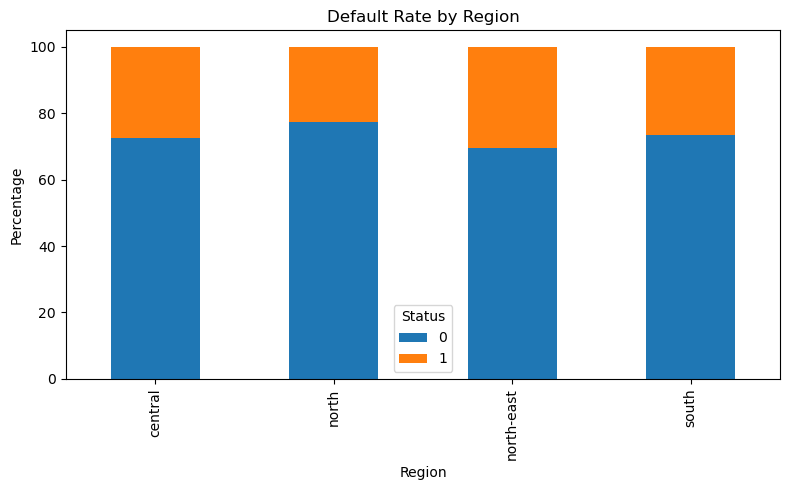

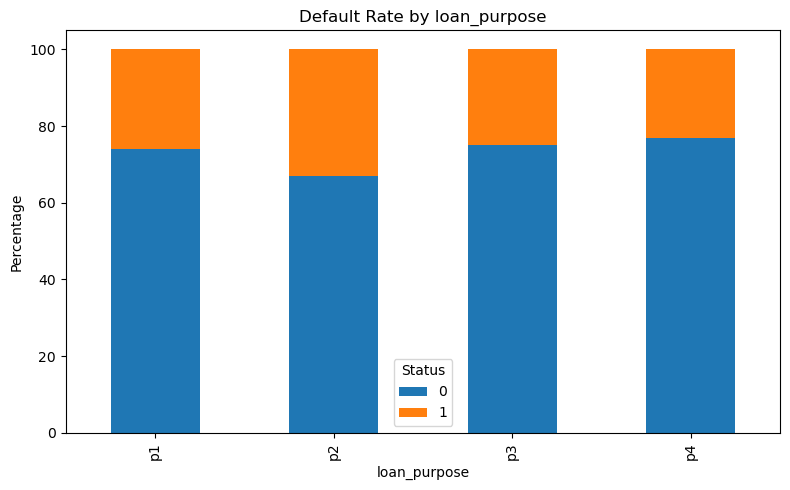

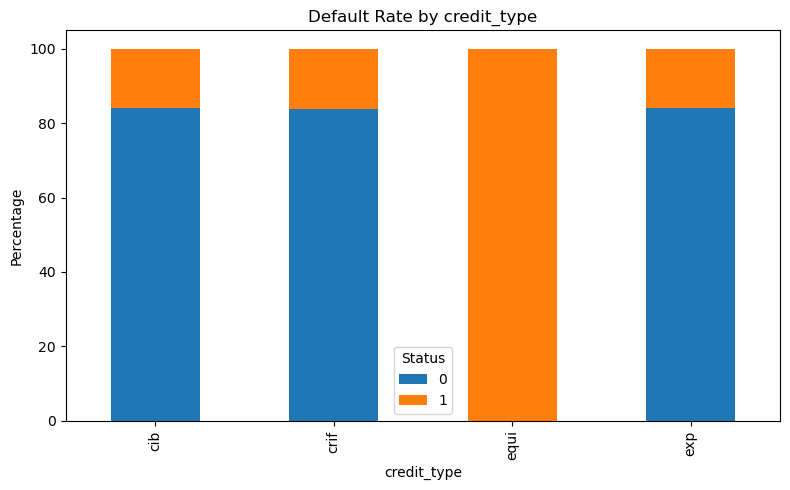

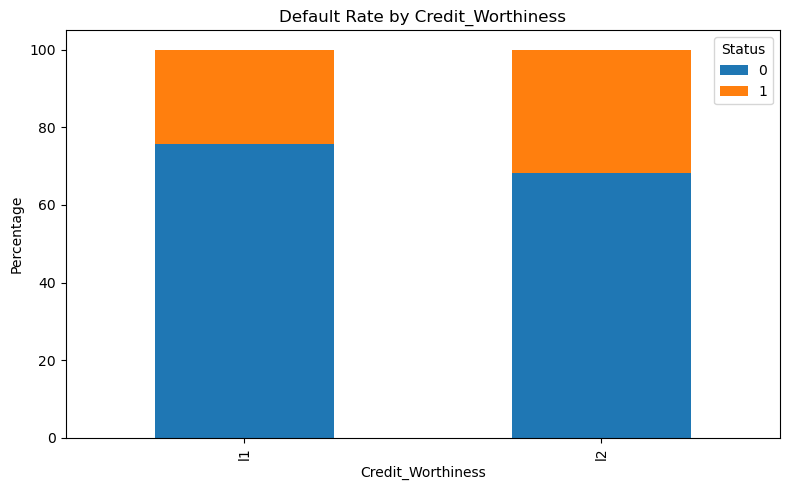

In [19]:
cat_cols = [
    'Gender',
    'Region',
    'loan_purpose',
    'credit_type',
    'Credit_Worthiness'
]

for col in cat_cols:
    
    default_rate = pd.crosstab(
        df[col],
        df['Status'],
        normalize='index'
    ) * 100

    default_rate.plot(
        kind='bar',
        stacked=True,
        figsize=(8,5)
    )

    plt.title(f"Default Rate by {col}")
    plt.ylabel("Percentage")
    plt.tight_layout()
    plt.show()

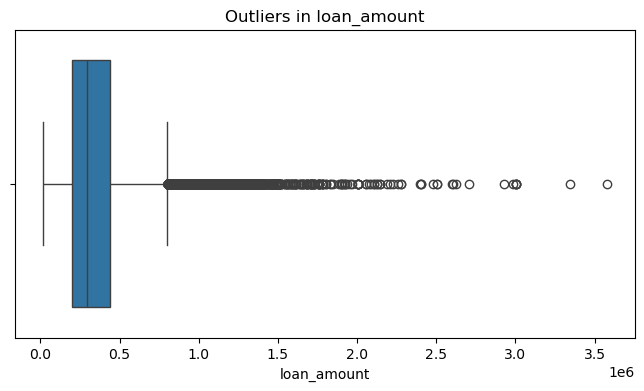

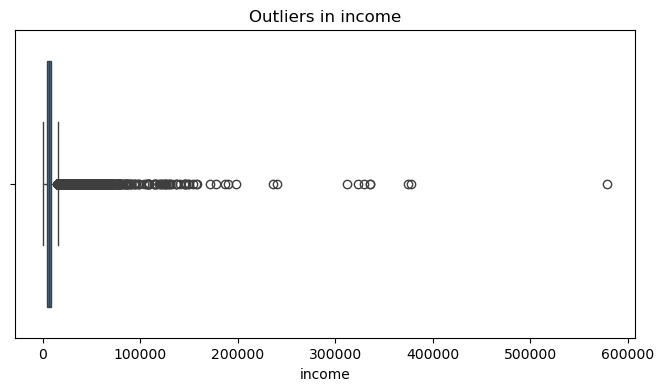

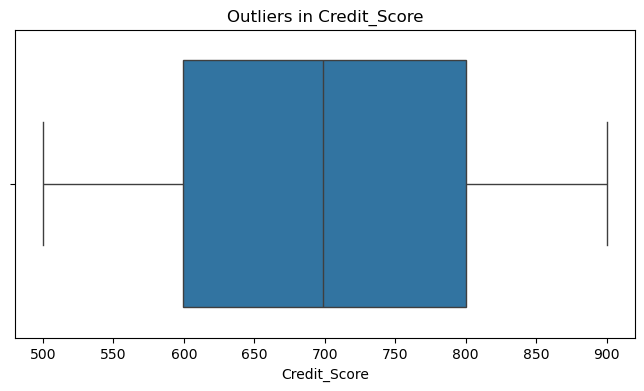

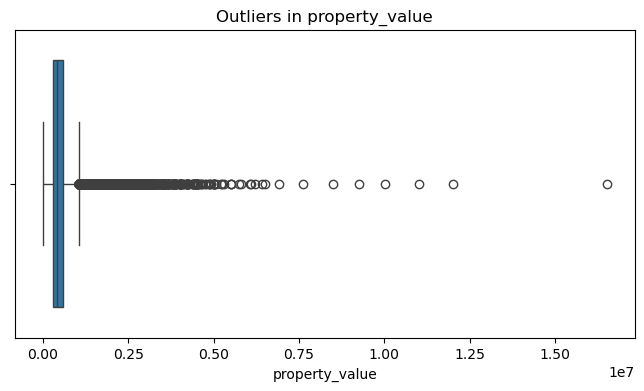

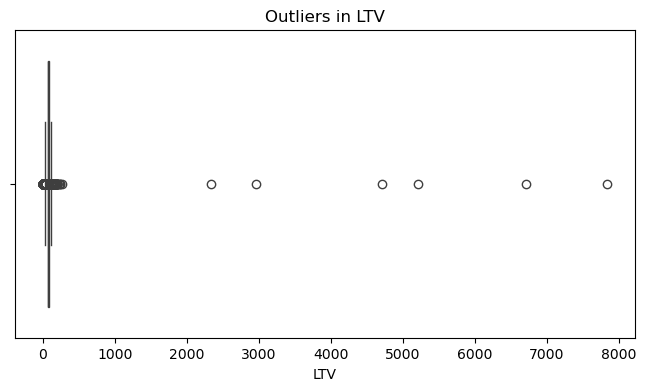

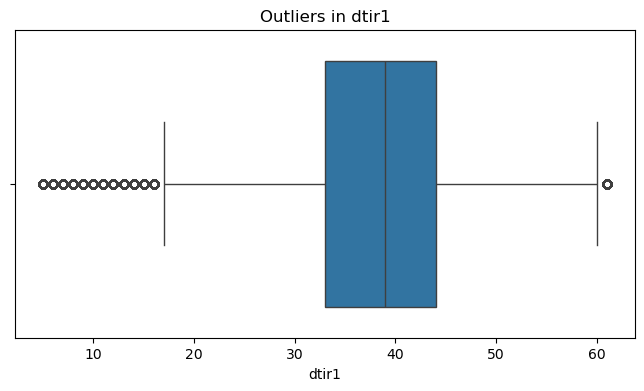

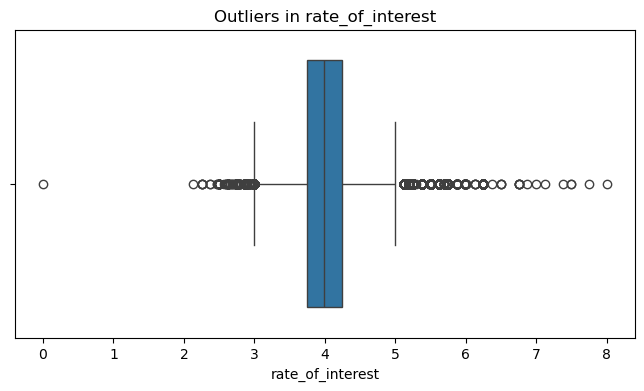

In [20]:
for col in num_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(
        x=df[col]
    )
    
    plt.title(f"Outliers in {col}")
    plt.show()